# ==========================================================
# Predicting Term Deposit Subscription using Bank Marketing Data
# ==========================================================

"""
This project develops and evaluates machine learning models to predict whether a
bank client will subscribe to a term deposit during a telemarketing campaign.

The analysis follows the CRISP-DM framework:
1. Data Loading
2. Initial Exploration
3. Exploratory Data Analysis (EDA)
4. Data Preparation
5. Modeling
6. Model Evaluation and Comparison
7. Conclusion

Because the dataset is imbalanced, model evaluation focuses on multiple metrics,
including precision, recall, F1-score, and ROC-AUC rather than accuracy alone.

In [1]:
# ============================================
# 1. Libraries and Imports
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import io

# 1. Data Loading

In this section, the dataset is loaded and prepared for analysis. Since the original CSV file may contain formatting inconsistencies (such as extra quotes or irregular delimiters), a preliminary cleaning step is applied before reading the data into a structured DataFrame.

This ensures that the dataset is correctly interpreted and avoids potential parsing issues in later stages.

In [2]:
# ============================================
# 2. Data Loading
# ============================================

# # Step 1: Read the raw CSV file as text
# # Read the raw CSV file as text
# with open('bank marketing.csv', 'r') as f:
#     lines = f.readlines()

# # Step 2: Clean each line by:
# # Trim whitespace, remove external quotes, and replace double quotes with single quotes
# def clean_line(line):
#     line = line.strip()
#     if line.startswith('"') and line.endswith('"'):
#         line = line[1:-1]
#     return line.replace('""', '"')

# # Apply cleaning to all lines
# cleaned_lines = [clean_line(line) for line in lines]

# # Convert the cleaned lines back to a single string
# cleaned_csv = "\n".join(cleaned_lines)

# # Step 3: Load dataset into pandas DataFrame
df_a = pd.read_csv("bank marketing.csv", sep=";", quotechar='"')

# 2. Initial Exploration

This section provides a first overview of the dataset structure, including its size, variable types, and general composition.

Understanding these aspects is essential before performing deeper analysis, as it helps identify potential data quality issues and guides subsequent preprocessing steps.

In [3]:
# ==========================================================
# 3. Initial structure checks
# ==========================================================

# Display dataset dimensions (rows, columns)
print("\n=== DATASET OVERVIEW ===")
print("Shape:", df_a.shape)

# List all column names
print("\nColumn names:")
display(pd.DataFrame({"Column": df_a.columns}))

# Check data types for each variable
print("\nData types:")
display(df_a.dtypes.to_frame(name="dtype"))

# Preview first rows to understand structure and values
print("\nFirst 5 rows:")
display(df_a.head())


=== DATASET OVERVIEW ===
Shape: (45211, 17)

Column names:


,Column
0,age
1,job
2,marital
3,education
4,default
5,balance
6,housing
7,loan
8,contact
9,day



Data types:


,dtype
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64



First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Before proceeding to exploratory analysis, several data quality checks are performed to identify potential issues such as duplicate records, missing values, and placeholder values (e.g., "unknown" or sentinel values like -1).

These checks are critical to ensure the reliability of the analysis and to inform appropriate data cleaning strategies.

In [4]:
# --------------------------------------------
# 4. Integrity checks
# --------------------------------------------
print("\n=== INTEGRITY CHECKS ===")

# Check for duplicate records
print("\nDuplicate rows:", df_a.duplicated().sum())

# Check for missing values across all columns
print("\nMissing values by column:")
display(df_a.isna().sum().sort_values(ascending=False).to_frame(name="Missing_Values"))

# Count unique values in each column to identify potential "unknown" entries
unknown_stats = (df_a == 'unknown').sum()

# Filter only columns that have at least one "unknown"
unknown_stats = unknown_stats[unknown_stats > 0]

print("\nValue audit 'unknown'")
print(unknown_stats)

# Identify the sentinel value 'unknown' in 'pdays' (which is a missing data point)
pdays_missing = (df_a['pdays'] == -1).sum()
print("\nValue audit 'pdays'")
print(f"pdays (-1: no contacted before): {pdays_missing}")


=== INTEGRITY CHECKS ===

Duplicate rows: 0

Missing values by column:


,Missing_Values
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0



Value audit 'unknown'
job            288
education     1857
contact      13020
poutcome     36959
dtype: int64

Value audit 'pdays'
pdays (-1: no contacted before): 36954


A summary of numerical and categorical variables is generated to understand distributions, central tendencies, and potential anomalies such as extreme values or skewness.

In [5]:
# --------------------------------------------
# 5. Basic numeric summary
# --------------------------------------------
print("\n=== NUMERIC SUMMARY ===")
display(df_a.describe(include="all").T)


=== NUMERIC SUMMARY ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


The dataset was successfully loaded with one target variable (`y`), and 16 predictors: 9 categoric variables and 7 numeric variables.

An initial audit was conducted to assess key data quality aspects, including dataset dimensions, duplicate records, missing values, class distribution, and the presence of placeholder values such as "unknown" and sentinel values like -1.

These checks are essential to ensure data reliability and to guide subsequent preprocessing steps. In particular, identifying inconsistencies and special value representations allows for more informed and justified data cleaning and transformation decisions, rather than relying on generic assumptions.

## 3. Exploratory Data Analysis (EDA)

This section examines the predictor set before preprocessing and modeling. The goal is to describe the data, assess class balance, compare feature scales, inspect distribution shape, and identify possible multicollinearity.

These checks are necessary because later preprocessing choices should be justified by the observed structure of the data rather than applied by default.

In [6]:
# ================================
# 6. Descriptive statistics
# ================================
eda_features = [col for col in df_a.columns if col not in ["y","job","marital","education","contact","month","poutcome"]]

desc_stats = df_a[eda_features].describe().T
desc_stats["range"] = desc_stats["max"] - desc_stats["min"]
desc_stats["iqr"] = desc_stats["75%"] - desc_stats["25%"]
desc_stats = desc_stats[["mean", "std", "min", "25%", "50%", "75%", "max", "range", "iqr"]]

print("Descriptive statistics for numeric predictors:")
display(desc_stats.head(30))

print("\nTop 10 features by standard deviation:")
display(desc_stats.sort_values("std", ascending=False).head(10))

print("\nTop 10 features by range:")
display(desc_stats.sort_values("range", ascending=False).head(10))

Descriptive statistics for numeric predictors:


,mean,std,min,25%,50%,75%,max,range,iqr
age,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0,77.0,15.0
balance,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0,110146.0,1356.0
day,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0,30.0,13.0
duration,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0,4918.0,216.0
campaign,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0,62.0,2.0
pdays,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0,872.0,0.0
previous,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0,275.0,0.0



Top 10 features by standard deviation:


,mean,std,min,25%,50%,75%,max,range,iqr
balance,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0,110146.0,1356.0
duration,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0,4918.0,216.0
pdays,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0,872.0,0.0
age,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0,77.0,15.0
day,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0,30.0,13.0
campaign,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0,62.0,2.0
previous,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0,275.0,0.0



Top 10 features by range:


,mean,std,min,25%,50%,75%,max,range,iqr
balance,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0,110146.0,1356.0
duration,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0,4918.0,216.0
pdays,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0,872.0,0.0
previous,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0,275.0,0.0
age,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0,77.0,15.0
campaign,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0,62.0,2.0
day,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0,30.0,13.0


The descriptive statistics reveal substantial variability across predictors. In particular, `balance` and `duration` show extremely high ranges and standard deviations, indicating the presence of large dispersion and potential outliers.

Additionally, variables such as `pdays` and `previous` contain a high concentration of low or zero values, suggesting possible zero-inflation or special encoding (e.g., -1 indicating no previous contact).

These observations highlight the need for further distribution analysis and potential transformations in later stages.

In [7]:
# ==============================================
# 7. Analyze unknown in categorical variables
# ==============================================

# Analyze unknown values using Chi-square test for categorical variables to determine relation with the target variable 'y'
cols = ['job','education','contact','poutcome']

for col in cols:
    contingency = pd.crosstab(df_a[col], df_a['y'])
    chi2, p, dof, expected = chi2_contingency(contingency)

    print(f"\nChi-square test for {col}")
    print("p-value:", p)


Chi-square test for job
p-value: 3.337121944935502e-172

Chi-square test for education
p-value: 1.6266562124072994e-51

Chi-square test for contact
p-value: 1.251738325340638e-225

Chi-square test for poutcome
p-value: 0.0


The Chi-square test results show extremely low p-values for all evaluated categorical variables, indicating a statistically significant association with the target variable.

This suggests that categorical features contain relevant predictive information. In particular, the presence of the "unknown" category is not random and may carry meaningful patterns related to customer behavior.

Therefore, instead of removing or imputing these values, they will be retained as valid categories for modeling.

### Distribution Shape and Skewness

Understanding the distribution of numerical variables is essential to detect skewness, outliers, and irregular patterns that may affect model performance.

Both histogram and count plots are used depending on the nature of each variable.

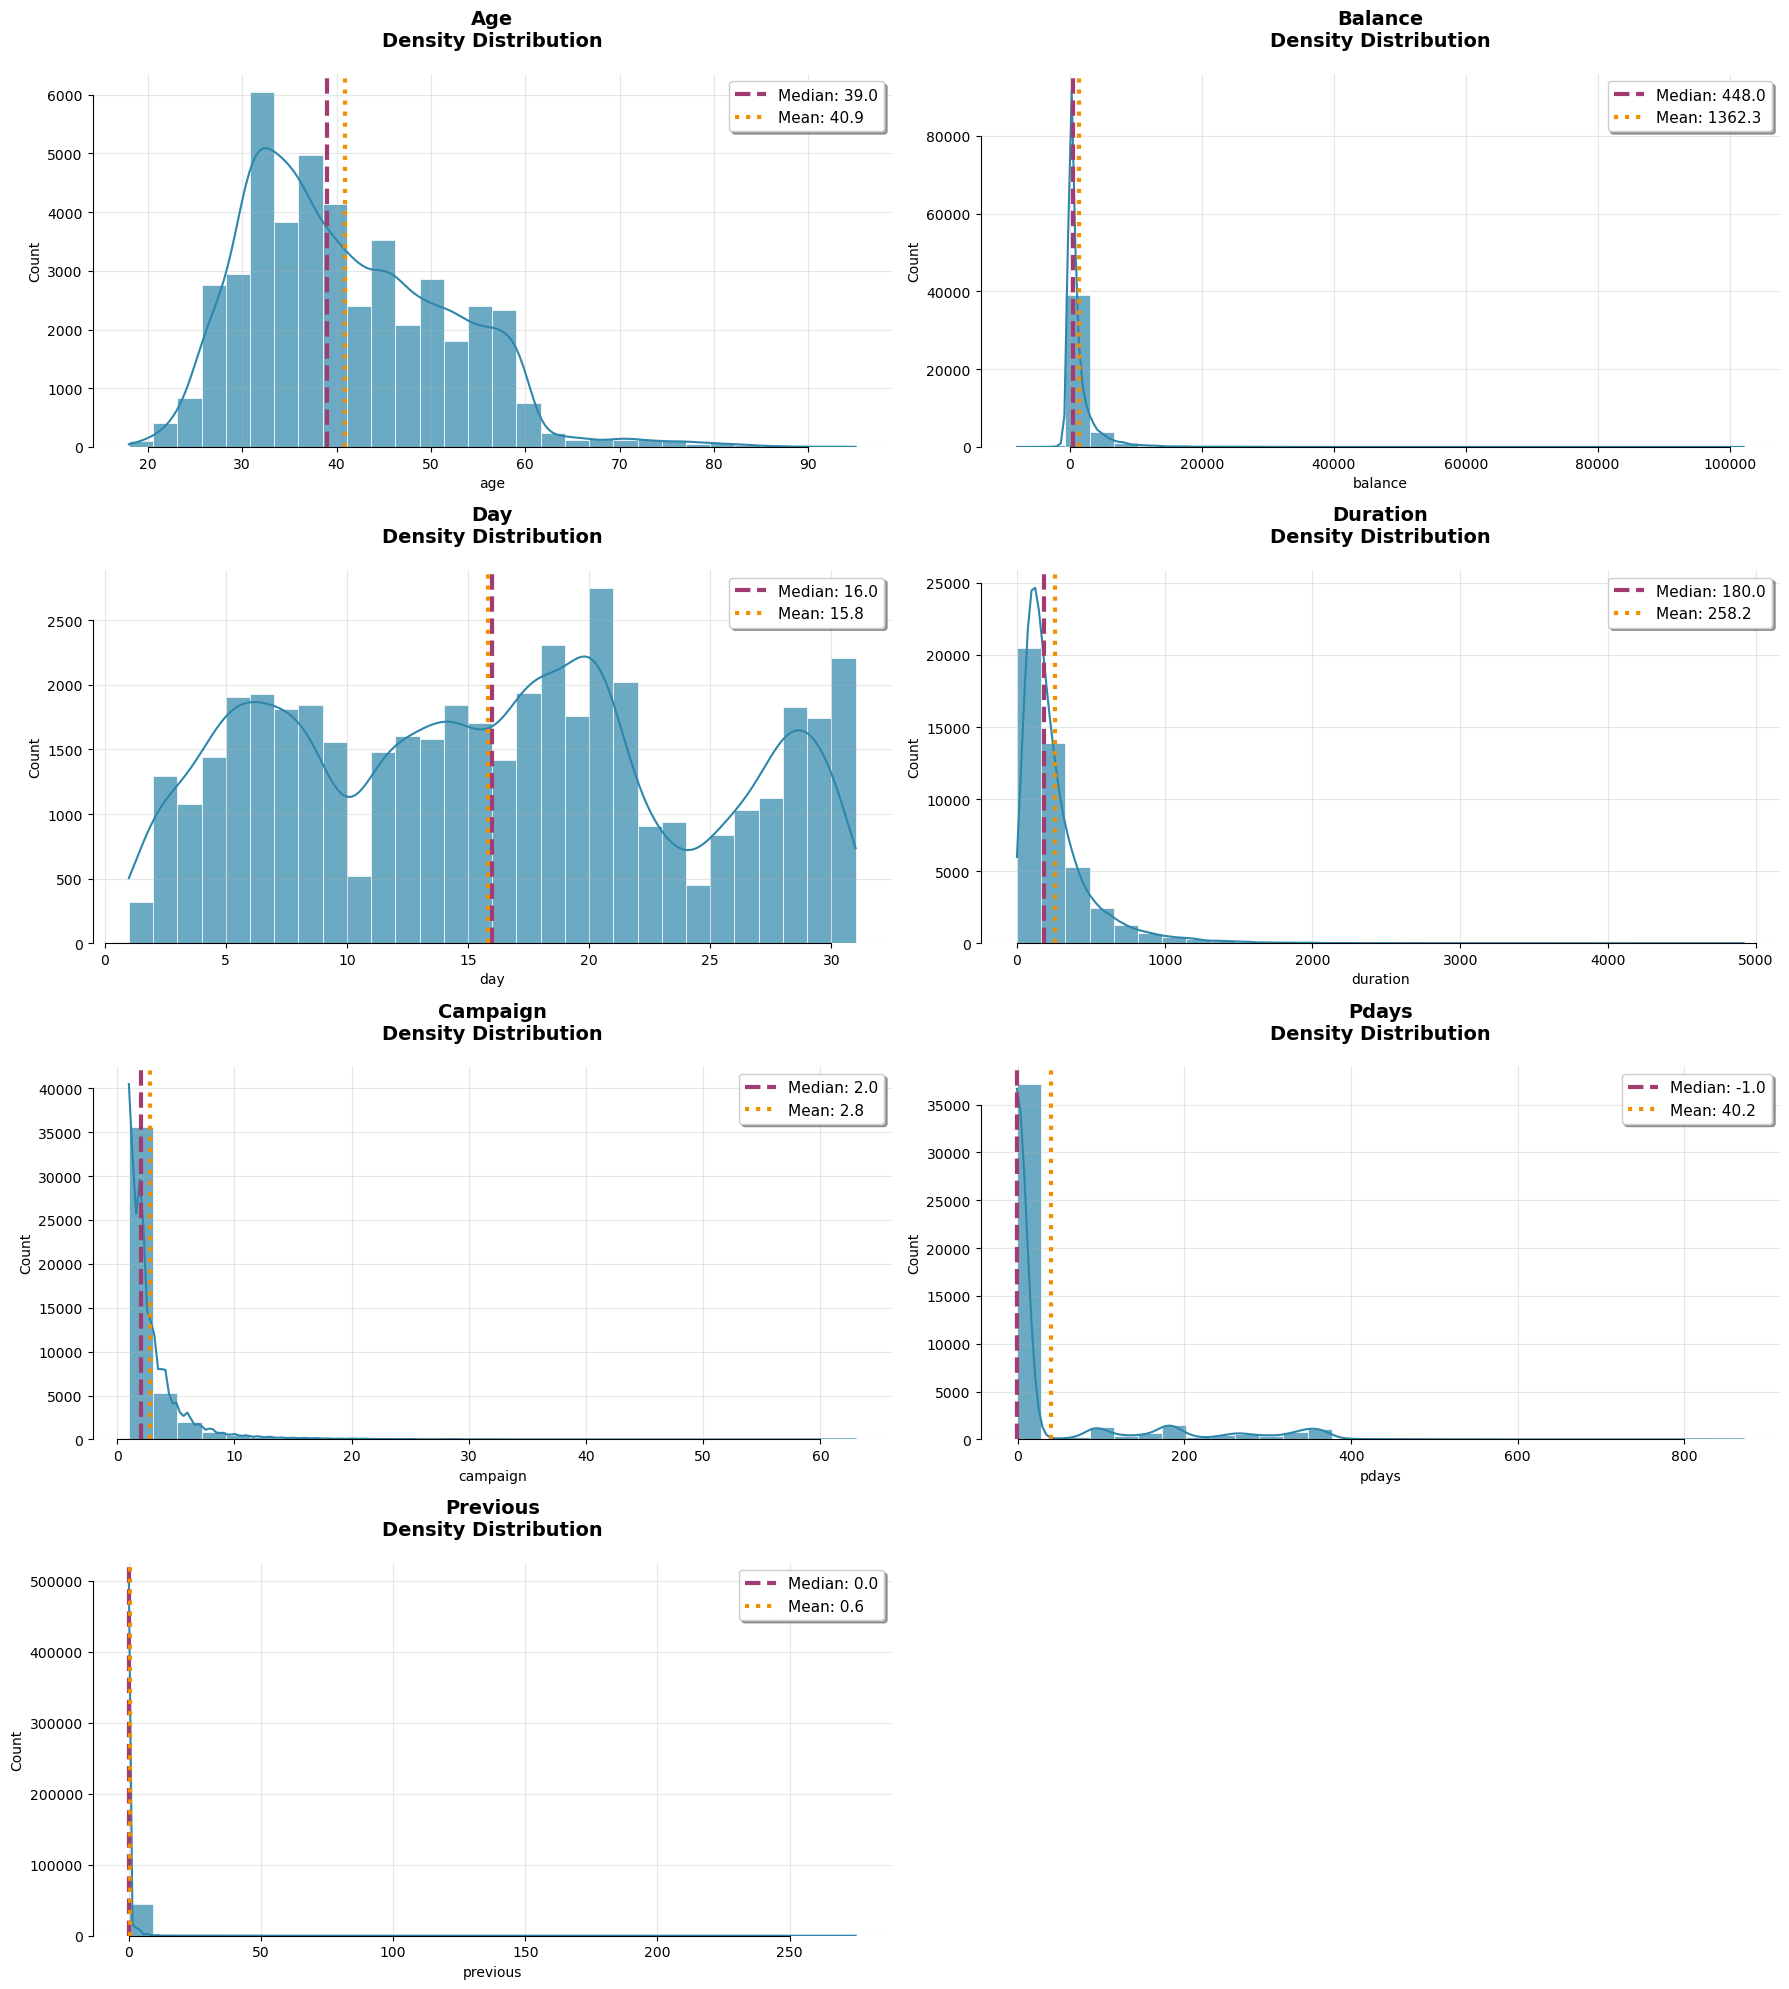

In [8]:
# =================================
# 8. Distribution Predictors
# =================================

numeric_features = df_a.select_dtypes(include=['int64','float64']).columns

# Remove target variable
numeric_features = [col for col in numeric_features if col != 'y']

# plt.style.use('seaborn-v0_8-whitegrid')
# sns.set_palette("husl")

n_cols = 2
n_rows = (len(numeric_features) + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
if n_rows == 1:
    axes = axes.flatten()
else:
    axes = axes.flatten()

for i, col in enumerate(numeric_features):
    ax = axes[i]

    sns.histplot(data=df_a, x=col, kde=True, bins=30, ax=ax,
                    color='#2E86AB', alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.axvline(df_a[col].median(), color='#A23B72', linestyle='--', linewidth=3, 
                  label=f'Median: {df_a[col].median():.1f}')
    ax.axvline(df_a[col].mean(), color='#F18F01', linestyle=':', linewidth=3, 
                  label=f'Mean: {df_a[col].mean():.1f}')
    ax.legend(fontsize=11, loc='upper right', frameon=True, shadow=True)
    ax.set_title(f'{col.replace("_", " ").title()}\nDensity Distribution', 
                    fontsize=14, fontweight='bold', pad=20)
    
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=10)
    sns.despine(ax=ax, trim=True)

# Hide empty subplots
for i in range(len(numeric_features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


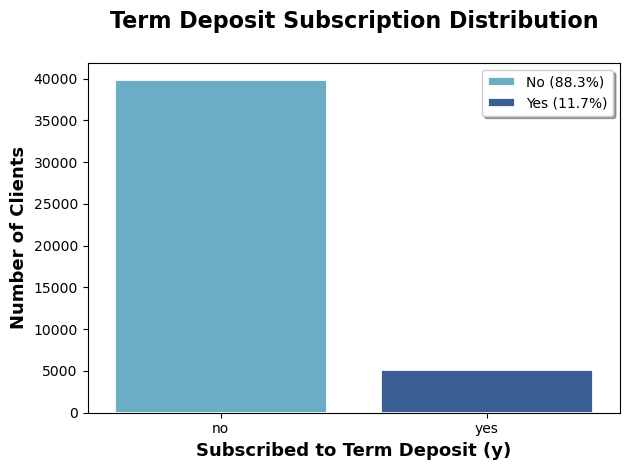

,y,Count,Proportion
0,no,39922,0.883
1,yes,5289,0.117


In [9]:
# =================================
# 9. Distribution Target
# =================================
# Barchart 
sns.countplot(data=df_a, x='y', hue='y', 
              palette=['#5BB4D3', '#2c5aa0'], 
              edgecolor='white', linewidth=2)
plt.title('Term Deposit Subscription Distribution', 
          fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Subscribed to Term Deposit (y)', fontsize=13, fontweight='bold')
plt.ylabel('Number of Clients', fontsize=13, fontweight='bold')
plt.grid(False)
plt.legend(['No (88.3%)', 'Yes (11.7%)'], frameon=True, shadow=True)

plt.tight_layout()
plt.show()


# Table with counts and proportions of each class in the target variable 'y'
class_counts = df_a["y"].value_counts().rename_axis("y").reset_index(name="Count")
class_counts["Proportion"] = (class_counts["Count"] / class_counts["Count"].sum()).round(4)

display(class_counts)

The distribution of the target variable shows a clear class imbalance, with a significantly higher proportion of non-subscribers compared to subscribers. This indicates that accuracy alone may not be a reliable performance metric, as a model predicting only the majority class could still achieve high accuracy.

Therefore, additional metrics such as precision, and recall will be considered in later stages of the analysis.

In [10]:
# ================================
# 10. Skewness analysis
# ================================

def detect_skewed_features(df_a, threshold=0.5):
    # Store information for features whose skewness exceeds the threshold
    skewed_info = []

    # Keep only numeric columns, since skewness is defined for numerical variables
    numeric_cols = [col for col in df_a.select_dtypes(include=[np.number]).columns if df_a[col].nunique() > 2]

    # Evaluate skewness for each numeric feature
    for col in numeric_cols:
        # Drop NaNs for skew calculation
        data = df_a[col].dropna()
        skew_val = skew(data, bias=False)

        # Flag features with substantial positive or negative skewness
        if abs(skew_val) > threshold:
            # Suggest Box-Cox for strictly positive data; otherwise use Yeo-Johnson
            suggestion = "Box-Cox" if (data > 0).all() else "Yeo-Johnson"
            skewed_info.append({
                'Feature': col,
                'Skewness': round(skew_val, 3),
                'Suggested Transformation': suggestion})

    return pd.DataFrame(skewed_info)

skewed_df = detect_skewed_features(df_a[numeric_features])
print(skewed_df)

    Feature  Skewness Suggested Transformation
0       age     0.685                  Box-Cox
1   balance     8.360              Yeo-Johnson
2  duration     3.144              Yeo-Johnson
3  campaign     4.899                  Box-Cox
4     pdays     2.616              Yeo-Johnson
5  previous    41.846              Yeo-Johnson


Skewness analysis was used as an initial screening step to guide transformation decisions. In the final modeling workflow, `campaign` was transformed using Box-Cox, while `age`, `balance`, and `day` were transformed using Yeo–Johnson after the train-test split. Variables related to prior campaign history were later consolidated through feature engineering rather than transformed directly.

In [11]:
# ================================
# 12. Outlier analysis
# ================================

# No trimming or winsorizing will be done, only diagnosis
# Select only continuous variables (no binary)
continuous_features = [
    'age', 'balance', 'day',
    'campaign', 'pdays', 'previous']

# Make summary of outliers
outlier_summary = []

for col in continuous_features:
    data = df_a[col].dropna()

    # Z-score method
    z_scores = (data - data.mean()) / data.std()
    z_outliers = data[np.abs(z_scores) > 3]

    # IQR method
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = data[(data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))]

    outlier_summary.append({
        'Column': col,
        'Z-Score Outliers': len(z_outliers),
        'IQR Outliers': len(iqr_outliers)})

# Convert to DataFrame for display
summary_df = pd.DataFrame(outlier_summary)
print(summary_df)

     Column  Z-Score Outliers  IQR Outliers
0       age               381           487
1   balance               745          4729
2       day                 0             0
3  campaign               840          3064
4     pdays              1723          8257
5  previous               582          8257


The outlier analysis shows that several variables, particularly `balance`, `campaign`, and `pdays`, contain a significant number of extreme values according to both Z-score and IQR methods.

However, in the context of marketing data, these extreme values may represent real customer behavior rather than data errors. Therefore, instead of removing them, their impact will be carefully evaluated during modeling, and transformations or robust algorithms may be preferred.

### Key Findings from EDA

The exploratory analysis reveals several important characteristics of the dataset:

- Predictors operate on vastly different scales, which supports later feature transformations.
- Numerical variables such as `balance`, `duration`, and `pdays` show high variability and strong skewness.
- Significant outliers are present but may reflect real-world behavior rather than noise.
- The target variable is highly imbalanced, requiring careful selection of evaluation metrics.
- Categorical variables are strongly associated with the target, and "unknown" values carry predictive information.

These findings justify the need for data transformation, encoding of categorical variables, and careful feature handling in the next stage of the project.

# 4. Data Preparation

This section prepares the dataset for modeling by performing data cleaning, feature adjustments, variable transformations, and exploratory correlation analysis.

All modeling-specific steps such as train-test splitting, encoding, scaling, and class imbalance handling will be implemented in the Modeling section to ensure a leakage-safe pipeline.

In [12]:
# ===================================
# 13. Data Cleaning
# ===================================

df_b = df_a.copy()

# Remove duration because it causes data leakage
df_b = df_b.drop(['duration'], axis = 1)

The variable `duration` was removed because it is only known after the call is completed, making it unavailable at prediction time. Including it would introduce data leakage and artificially inflate model performance.

These step ensure that the dataset reflects only information available at the time of decision-making.

In [13]:
# =========================================
# 14. Feature Processing  (before split)
# =========================================

df_c = df_b.copy()

# Rename columns for clarity
new_column_names = [
    'Age', 'Occupation', 'Marital_Status', 'Education_Level', 'Credit_Default', 'Avg_Yearly_Balance', 
    'Housing_Loan', 'Personal_Loan', 'Contact_Method', 'Last_Contact_Day', 'Last_Contact_Month',
    'Campaign_Contacts', 'Days_Since_Previous_Contact', 'Previous_Contacts', 'Previous_Campaign_Outcome','Sub_Term_Deposit']

# Assign the new column names
df_c.columns = new_column_names

# Convert target variable to binary (1 = subscribed, 0 = not subscribed)
df_c['Sub_Term_Deposit'] = df_c['Sub_Term_Deposit'].map({'yes':1, 'no':0})

# Transform predictors
binary_cols = [ 'Credit_Default', 'Housing_Loan', 'Personal_Loan']

#Apply mapping to convert 'yes'/'no' to 1/0
for col in binary_cols:
    df_c[col] = df_c[col].map({'yes': 1, 'no': 0})

# Final modeling table preview
print("\nNew Dataset Info:")
display(df_c.info())

print("\nNew First 5 rows:")
display(df_c.head())


New Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Age                          45211 non-null  int64 
 1   Occupation                   45211 non-null  object
 2   Marital_Status               45211 non-null  object
 3   Education_Level              45211 non-null  object
 4   Credit_Default               45211 non-null  int64 
 5   Avg_Yearly_Balance           45211 non-null  int64 
 6   Housing_Loan                 45211 non-null  int64 
 7   Personal_Loan                45211 non-null  int64 
 8   Contact_Method               45211 non-null  object
 9   Last_Contact_Day             45211 non-null  int64 
 10  Last_Contact_Month           45211 non-null  object
 11  Campaign_Contacts            45211 non-null  int64 
 12  Days_Since_Previous_Contact  45211 non-null  int64 
 13  Previous_Con

None


New First 5 rows:


,Age,Occupation,Marital_Status,Education_Level,Credit_Default,Avg_Yearly_Balance,Housing_Loan,Personal_Loan,Contact_Method,Last_Contact_Day,Last_Contact_Month,Campaign_Contacts,Days_Since_Previous_Contact,Previous_Contacts,Previous_Campaign_Outcome,Sub_Term_Deposit
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,1,-1,0,unknown,0
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,0,1506,1,0,unknown,5,may,1,-1,0,unknown,0
4,33,unknown,single,unknown,0,1,0,0,unknown,5,may,1,-1,0,unknown,0


Column names were standardized to improve readability and interpretability during analysis and modeling.

Binary categorical variables were converted into numerical format (0/1) to ensure compatibility with machine learning algorithms.

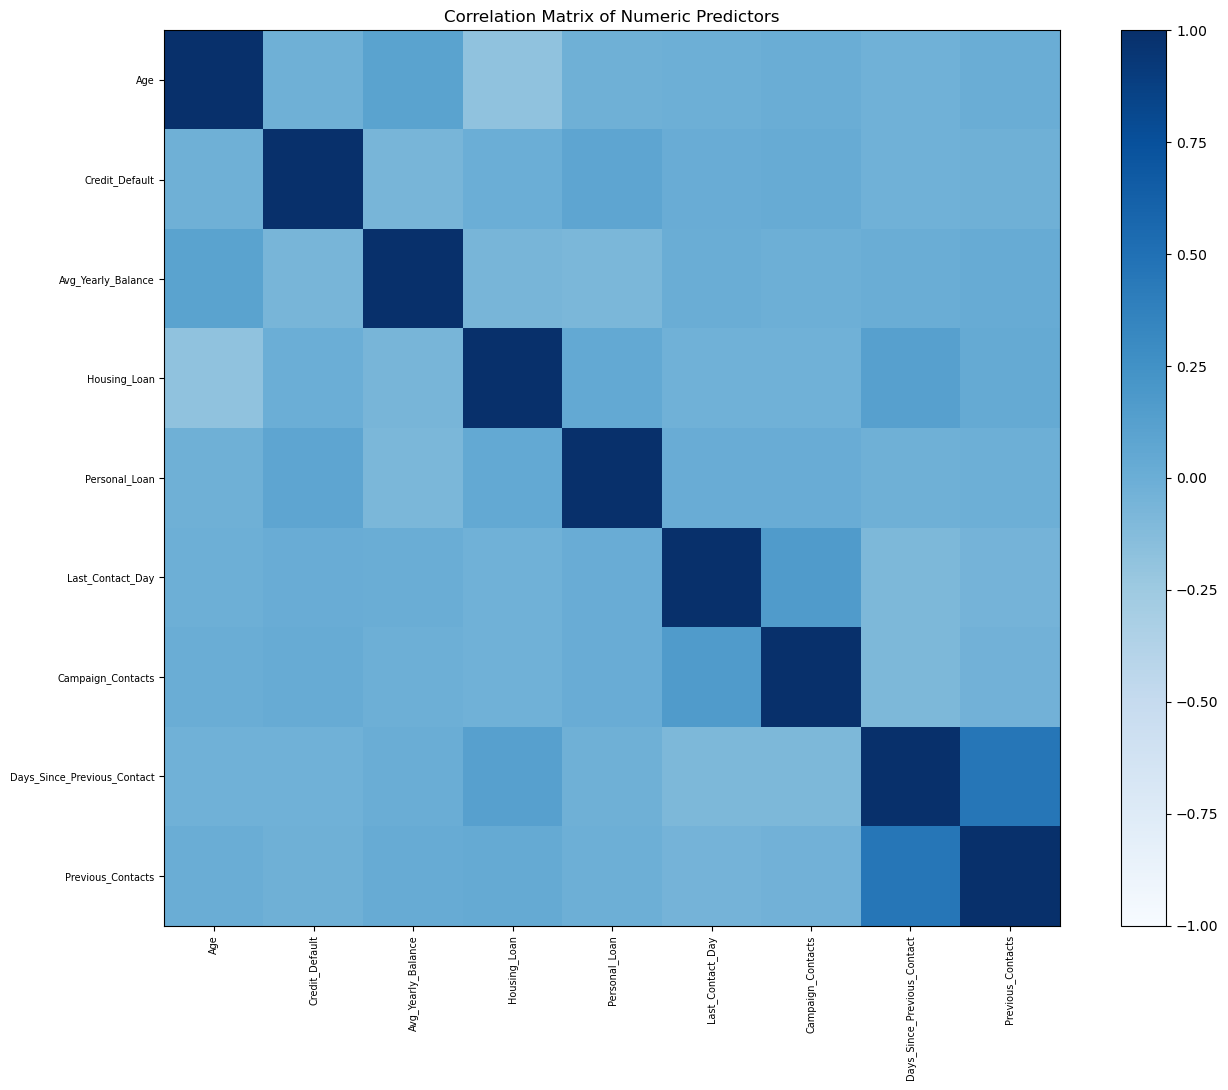

Top 15 strongest absolute correlations:


,feature_1,feature_2,correlation,abs_corr
35,Days_Since_Previous_Contact,Previous_Contacts,0.454820,0.454820
2,Age,Housing_Loan,-0.185513,0.185513
30,Last_Contact_Day,Campaign_Contacts,0.162490,0.162490
24,Housing_Loan,Days_Since_Previous_Contact,0.124178,0.124178
1,Age,Avg_Yearly_Balance,0.097783,0.097783
31,Last_Contact_Day,Days_Since_Previous_Contact,-0.093044,0.093044
33,Campaign_Contacts,Days_Since_Previous_Contact,-0.088628,0.088628
16,Avg_Yearly_Balance,Personal_Loan,-0.084350,0.084350
10,Credit_Default,Personal_Loan,0.077234,0.077234
15,Avg_Yearly_Balance,Housing_Loan,-0.068768,0.068768


In [14]:
# ================================
# 15. Correlation analysis
# ================================
num_features = [col for col in df_c.columns if col not in ["Sub_Term_Deposit","Occupation","Marital_Status","Education_Level","Contact_Method","Last_Contact_Month","Previous_Campaign_Outcome"]]

corr_matrix = df_c[num_features].corr()

plt.figure(figsize=(14, 11))
plt.imshow(corr_matrix, cmap='Blues', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numeric Predictors")
plt.colorbar()
plt.xticks(range(len(num_features)), num_features, rotation=90, fontsize=7)
plt.yticks(range(len(num_features)), num_features, fontsize=7)
plt.tight_layout()
plt.show()

# Extract strongest absolute correlations (excluding self-correlation)
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs_long = corr_pairs.stack().reset_index()
corr_pairs_long.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs_long["abs_corr"] = corr_pairs_long["correlation"].abs()

top_corr = corr_pairs_long.sort_values("abs_corr", ascending=False).head(15)

print("Top 15 strongest absolute correlations:")
display(top_corr)

Correlation analysis is conducted after transforming binary variables into a numerical format to ensure that all relevant predictors are included in the analysis.

Since correlation measures linear relationships between numerical variables, categorical variables are not considered at this stage.

This approach allows for a more complete assessment of relationships between predictors, particularly those that were originally categorical but are now represented in numeric form.

It is important to note that this step remains exploratory in nature and is used to identify potential multicollinearity issues before modeling, rather than to perform feature selection at this stage.

In [15]:
# ================================
# 16. Feature Engineering
# ================================

# Create a new feature summarizing previous interaction status
df_c['Previous_Interaction_Status'] = 'Other'

df_c.loc[df_c['Days_Since_Previous_Contact'] == -1, 'Previous_Interaction_Status'] = 'Never_Contacted'
df_c.loc[df_c['Previous_Campaign_Outcome'] == 'success', 'Previous_Interaction_Status'] = 'Success'
df_c.loc[df_c['Previous_Campaign_Outcome'] == 'failure', 'Previous_Interaction_Status'] = 'Failure'

# Drop redundant variables to avoid multicollinearity and data leakage
df_c = df_c.drop(columns=[
    'Days_Since_Previous_Contact',
    'Previous_Campaign_Outcome',
    'Previous_Contacts'])


# 5. Modeling

In this section, the dataset is finalized through feature engineering, followed by the definition of predictors and the target variable. A stratified train-test split is applied to ensure a robust and unbiased evaluation framework.

Feature transformations are then performed using One-Hot Encoding and power transformations (Box-Cox and Yeo-Johnson). Class imbalance is addressed through weighting techniques incorporated within the modeling stage.

Finally, multiple machine learning models are trained and evaluated, including Logistic Regression, Random Forest, and XGBoost.

In [16]:

# =============================================
# 17. Export Cleaned and Transformed Dataset
# =============================================

# The final cleaned dataset is exported for reproducibility and submission as a separate deliverable

# Create final cleaned dataset
df_final = df_c.copy()

# Export to CSV
df_final.to_csv("cleaned_transformed_dataset.csv", index=False)
print("Dataset exported successfully.")

# ================================
# 18. Define predictors and target
# ================================

# Separate features and target variable
y = df_c['Sub_Term_Deposit']
X = df_c.drop(columns=['Sub_Term_Deposit'])

print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nTarget distribution before split:")
print(y.value_counts().sort_index())
print(y.value_counts(normalize=True).sort_index().round(4))

# ================================
# 19. Stratified train-test split
# ================================

from sklearn.model_selection import train_test_split

# Perform stratified split to preserve class distribution
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTrain shape:", X_train_raw.shape)
print("Test shape:", X_test_raw.shape)

print("\nTrain target distribution:")
print(y_train.value_counts().sort_index())
print(y_train.value_counts(normalize=True).sort_index().round(4))

print("\nTest target distribution:")
print(y_test.value_counts().sort_index())
print(y_test.value_counts(normalize=True).sort_index().round(4))

# ================================
# 20. Feature groups (UPDATED)
# ================================

# Nominal categorical variables (including engineered feature)
nominal_features = [
    'Occupation', 'Marital_Status', 'Education_Level',
    'Contact_Method', 'Last_Contact_Month',
    'Previous_Interaction_Status']

# Binary variables (already encoded as 0/1)
binary_features = [
    'Credit_Default', 'Housing_Loan', 'Personal_Loan']

# Continuous variables separated by transformation type (based on skewness analysis)
boxcox_features = ['Campaign_Contacts']  # strictly positive
yeojohnson_features = ['Age', 'Avg_Yearly_Balance', 'Last_Contact_Day']  # can include zero or negative

# ====================================
# 21. One-Hot Encoding (Train only)
# ====================================

from sklearn.preprocessing import OneHotEncoder

OHE = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

X_train_nominal = OHE.fit_transform(X_train_raw[nominal_features])
X_test_nominal  = OHE.transform(X_test_raw[nominal_features])

# ================================
# 22. Feature Transformation
# ================================

from sklearn.preprocessing import PowerTransformer

# Apply Box-Cox transformation (only for strictly positive features)
pt_boxcox = PowerTransformer(method='box-cox', standardize=True)

X_train_boxcox = pt_boxcox.fit_transform(X_train_raw[boxcox_features])
X_test_boxcox  = pt_boxcox.transform(X_test_raw[boxcox_features])

# Apply Yeo-Johnson transformation (handles zero and negative values)
pt_yeojohnson = PowerTransformer(method='yeo-johnson', standardize=True)

X_train_yeo = pt_yeojohnson.fit_transform(X_train_raw[yeojohnson_features])
X_test_yeo  = pt_yeojohnson.transform(X_test_raw[yeojohnson_features])

# ================================
# 23. Convert to DataFrames
# ================================

import pandas as pd

# Nominal features
X_train_nom_df = pd.DataFrame(
    X_train_nominal,
    columns=OHE.get_feature_names_out(nominal_features),
    index=X_train_raw.index)

X_test_nom_df = pd.DataFrame(
    X_test_nominal,
    columns=OHE.get_feature_names_out(nominal_features),
    index=X_test_raw.index)

# Box-Cox features
X_train_boxcox_df = pd.DataFrame(
    X_train_boxcox,
    columns=boxcox_features,
    index=X_train_raw.index)

X_test_boxcox_df = pd.DataFrame(
    X_test_boxcox,
    columns=boxcox_features,
    index=X_test_raw.index)

# Yeo-Johnson features
X_train_yeo_df = pd.DataFrame(
    X_train_yeo,
    columns=yeojohnson_features,
    index=X_train_raw.index)

X_test_yeo_df = pd.DataFrame(
    X_test_yeo,
    columns=yeojohnson_features,
    index=X_test_raw.index)

# ================================
# 24. Combine all features
# ================================

# Concatenate all processed feature groups
X_train_combined = pd.concat(
    [X_train_nom_df,
     X_train_raw[binary_features],
     X_train_boxcox_df,
     X_train_yeo_df],
    axis=1)

X_test_combined = pd.concat(
    [X_test_nom_df,
     X_test_raw[binary_features],
     X_test_boxcox_df,
     X_test_yeo_df],
    axis=1)

print("\nFinal shapes:")
print("X_train:", X_train_combined.shape)
print("X_test:", X_test_combined.shape)


Dataset exported successfully.
Predictor matrix shape: (45211, 13)
Target vector shape: (45211,)

Target distribution before split:
Sub_Term_Deposit
0    39922
1     5289
Name: count, dtype: int64
Sub_Term_Deposit
0    0.883
1    0.117
Name: proportion, dtype: float64

Train shape: (36168, 13)
Test shape: (9043, 13)

Train target distribution:
Sub_Term_Deposit
0    31937
1     4231
Name: count, dtype: int64
Sub_Term_Deposit
0    0.883
1    0.117
Name: proportion, dtype: float64

Test target distribution:
Sub_Term_Deposit
0    7985
1    1058
Name: count, dtype: int64
Sub_Term_Deposit
0    0.883
1    0.117
Name: proportion, dtype: float64

Final shapes:
X_train: (36168, 39)
X_test: (9043, 39)


After applying all transformations, the processed feature sets are combined into a single dataset. This ensures that all variables are properly encoded and scaled before being used in the modeling stage.

To further validate the feature space, the Variance Inflation Factor (VIF) is calculated to assess potential multicollinearity. High VIF values can destabilize coefficient estimates in Logistic Regression, making this step important for ensuring reliable model performance.

### Handling Class Imbalance

Given the strong class imbalance (88% non-subscribers vs 12% subscribers), specific techniques are applied during the modeling stage to ensure that the minority class is properly learned.

For Logistic Regression and Random Forest, class weights are adjusted to penalize misclassification of the minority class. For XGBoost, the scale_pos_weight parameter is used to rebalance the training process.

These approaches improve the model’s ability to detect potential subscribers by prioritizing the minority class, leading to higher recall and precision in an imbalanced classification setting.

In [17]:
# ================================
# 25. Class balance analysis
# ================================

# Summarize class balance
train_class_summary = pd.DataFrame({
    "count": y_train.value_counts().sort_index(),
    "proportion": y_train.value_counts(normalize=True).sort_index().round(4)})

test_class_summary = pd.DataFrame({
    "count": y_test.value_counts().sort_index(),
    "proportion": y_test.value_counts(normalize=True).sort_index().round(4)})

print("Training class summary:")
display(train_class_summary)

print("\nTest class summary:")
display(test_class_summary)

Training class summary:


,count,proportion
Sub_Term_Deposit,,
0,31937,0.883
1,4231,0.117



Test class summary:


,count,proportion
Sub_Term_Deposit,,
0,7985,0.883
1,1058,0.117


Class distribution remains highly imbalanced in both training and test sets. Using class-weighted models ensures that minority class predictions (subscribers) are not ignored.

In [18]:
# ================================
# 26. Evaluation functions
# ================================

results = {}
def evaluate_model(model, X_test_data, y_test_data, model_name):
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:,1]
    
    print(f"\n{'='*15} {model_name} Performance {'='*15}")
    print(f"Accuracy:  {accuracy_score(y_test_data, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test_data, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test_data, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test_data, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test_data, y_prob):.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test_data, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted No', 'Predicted Yes'], 
                yticklabels=['Actual No', 'Actual Yes'],
                cbar_kws={'label': 'Count', 'shrink': 0.8})
    plt.title(f"Confusion Matrix\n{model_name.replace('Model', '').title()}", 
              fontsize=16, fontweight='bold', pad=25, color='#2c3e50')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test_data, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='#2E86AB', lw=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')  
    plt.plot([0,1],[0,1], color='#bdc3c7', linestyle='--', lw=2, alpha=0.7)
    plt.fill_between(fpr, tpr, alpha=0.3, color='#4DA8C4') 
    
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title(f"ROC Curve\n{model_name.replace('Model', '').title()}", 
              fontsize=16, fontweight='bold', pad=25, color='#2c3e50')
    plt.legend(loc='lower right', frameon=True, shadow=True, fontsize=11)
    plt.grid(True, alpha=0.3)
    sns.despine()
    plt.tight_layout()
    plt.show()

    global results
    results[model_name] = {'cm': cm, 'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}


def plot_pr_curve(model, X_test, y_test, model_name):
    y_prob = model.predict_proba(X_test)[:,1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.figure(figsize=(8,6))
    plt.plot(recall, precision, lw=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {model_name}")
    plt.grid(True)
    plt.show()

# ==============================================
# 27. Functions to train and store metrics
# ==============================================
model_comparison = []

def train_evaluate_store(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    
    if hasattr(model, "best_estimator_"):
        model = model.best_estimator_
    
    evaluate_model(model, X_test, y_test, name)
    
    # Default threshold = 0.5
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    model_comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)})
    
def get_metrics_threshold(y_test, y_prob, threshold, name):

    y_pred = (y_prob >= threshold).astype(int)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)}    

In [19]:
# VIF may be inflated for One-Hot Encoded variables due to inherent multicollinearity.
# This does not necessarily indicate a problem for tree-based models. Select only numeric features for VIF calculation (after transformations)
X_vif = X_train_combined.copy()

# Create dataframe to save VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Display VIF, sorted descending
print("Variance Inflation Factor (VIF) for each feature:")
display(vif_data.sort_values("VIF", ascending=False).head(10))
print("No severe multicollinearity detected (VIF < 10 for most variables)")

Variance Inflation Factor (VIF) for each feature:


,feature,VIF
29,Previous_Interaction_Status_Never_Contacted,8.851068
25,Last_Contact_Month_may,5.425063
11,Marital_Status_married,5.414223
13,Education_Level_secondary,4.338066
14,Education_Level_tertiary,4.271134
3,Occupation_management,3.535506
12,Marital_Status_single,3.530727
17,Contact_Method_unknown,3.323231
23,Last_Contact_Month_jun,3.247322
33,Housing_Loan,3.010897


No severe multicollinearity detected (VIF < 10 for most variables)


Because no VIF exceeded 10 and model performance remained stable, no additional predictor removal was performed.

Some variables show VIF values between 5 and 10, indicating moderate multicollinearity. However, this is expected due to the use of one-hot encoding for categorical variables. 

Since no variables exceed the critical threshold of 10, and model performance is not negatively affected, no variables were removed based on VIF. This ensures that relevant information is preserved while maintaining model stability.

## Model Training and Evaluation

Multiple models are trained to compare performance under class imbalance:

1. DummyClassifier Baseline
2. Logistic Regression (Pipeline)
3. Logistic Regression Balanced
4. Random Forest (GridSearchCV tuning)
5. XGBoost (GridSearchCV tuning, scale_pos_weight)

Metrics of interest: Accuracy, Precision, Recall, F1-Score, ROC-AUC, PR-AUC.

### DummyClassifier Baseline

This trivial baseline always predicts the most frequent class. It serves as a minimum reference; all subsequent models must outperform this baseline.


=============== Dummy Baseline Performance ===============
Accuracy:  0.8830
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.5000


c:\Users\luise\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


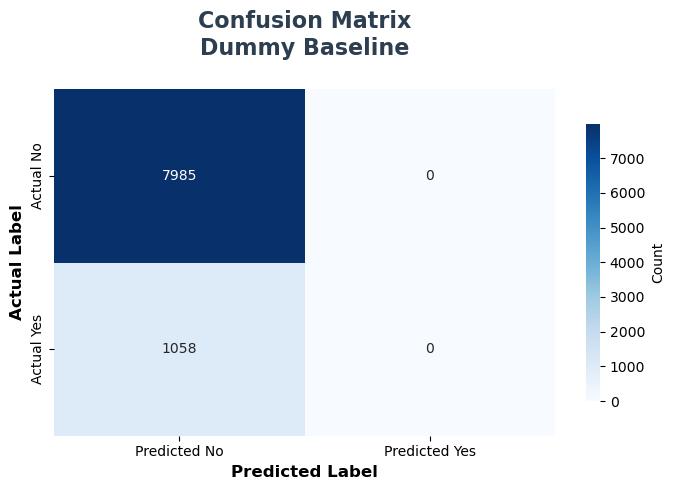

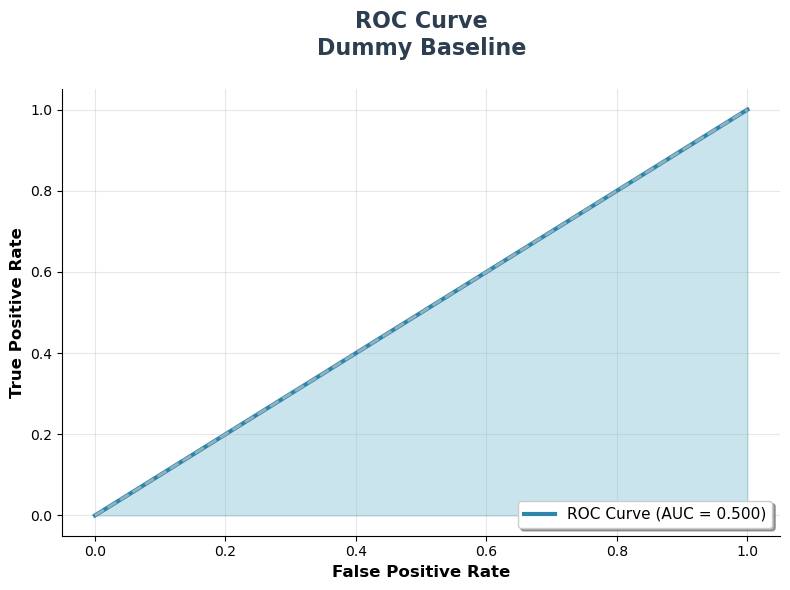

c:\Users\luise\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize DummyClassifier
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
train_evaluate_store(
    dummy,
    X_train_combined,
    y_train,
    X_test_combined,
    y_test,
    "Dummy Baseline")

### Model 1: Pipeline Logistic Regression, "liblinear" Method with L1 (LASSO) Penalty

Model 1 applies preprocessing via ColumnTransformer and L1 regularization on imbalanced data to identify important features while training on imbalanced data without class weighting. Serves as a first "real" model after the trivial baseline.


=============== Pipeline Logistic Regression Performance ===============
Accuracy:  0.8936
Precision: 0.6690
Recall:    0.1796
F1-Score:  0.2832
ROC-AUC:   0.7724


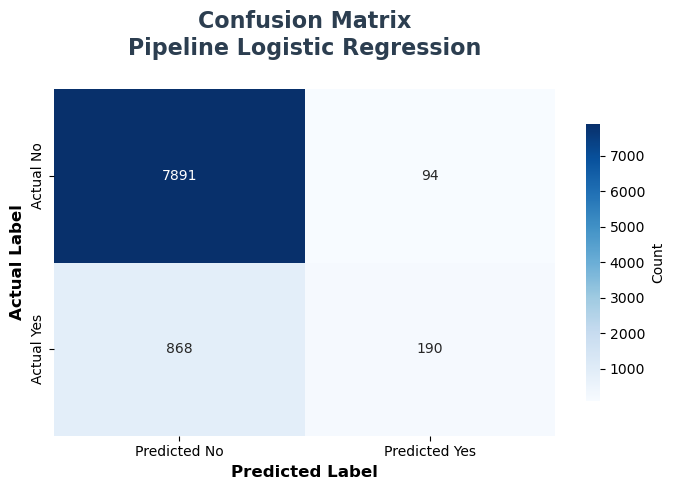

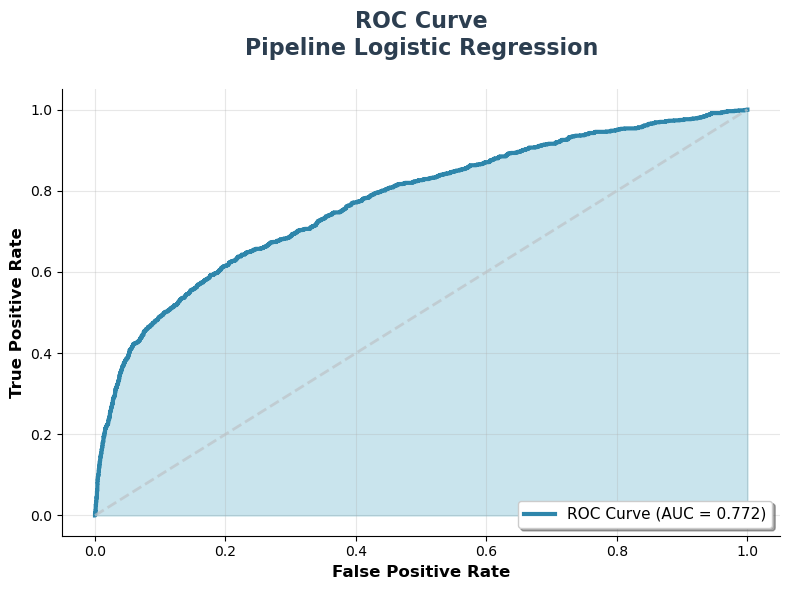

In [21]:
# =======================================
# Model 1: Pipeline Logistic Regression
# =======================================

# Define feature groups (CONSISTENT WITH DATA)
continuous_features = [
    'Age',
    'Avg_Yearly_Balance',
    'Last_Contact_Day',
    'Campaign_Contacts']

nominal_features = [
    'Occupation', 'Marital_Status', 'Education_Level',
    'Contact_Method', 'Last_Contact_Month',
    'Previous_Interaction_Status']

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', PowerTransformer(method='yeo-johnson'), continuous_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_features)],
    remainder='passthrough')

# Pipeline
pipeline_logistic = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(
        solver='liblinear',
        penalty='l1',
        random_state=42))])

# Train & evaluate
train_evaluate_store(
    pipeline_logistic,
    X_train_raw,
    y_train,
    X_test_raw,
    y_test,
    "Pipeline Logistic Regression")

The baseline Logistic Regression achieves high overall accuracy (0.8936) and strong precision (0.6690), indicating that when the model predicts a subscriber, it is often correct. However, recall is very low (0.1796), meaning that the model fails to identify a large proportion of actual subscribers.

This behavior reflects the impact of class imbalance, where the model is biased toward predicting the majority class. As a result, while performance appears strong based on accuracy, the model is not effective for the business objective of identifying potential subscribers. This highlights the limitation of accuracy as a standalone metric and the need to prioritize recall in this context.

### Model 2: Logistic Regression, class_weight="balanced"

This model incorporates class weights to address the imbalance in the target variable. By assigning higher importance to the minority class (subscribers), the model aims to improve recall and better capture positive cases.


=============== Logistic Regression Balanced Performance ===============
Accuracy:  0.7611
Precision: 0.2755
Recall:    0.6389
F1-Score:  0.3850
ROC-AUC:   0.7731


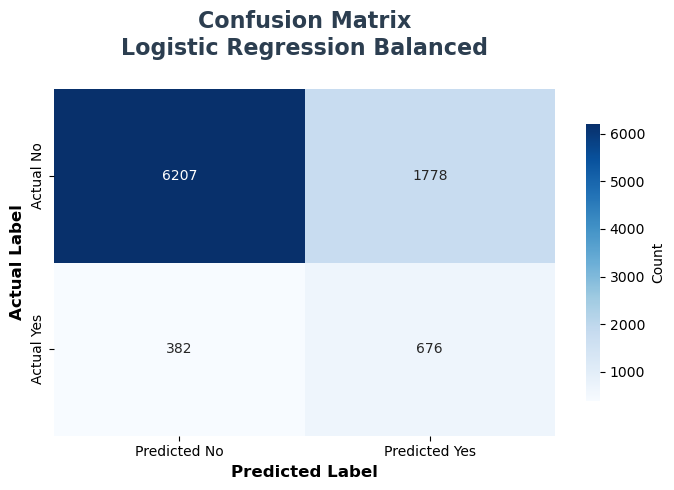

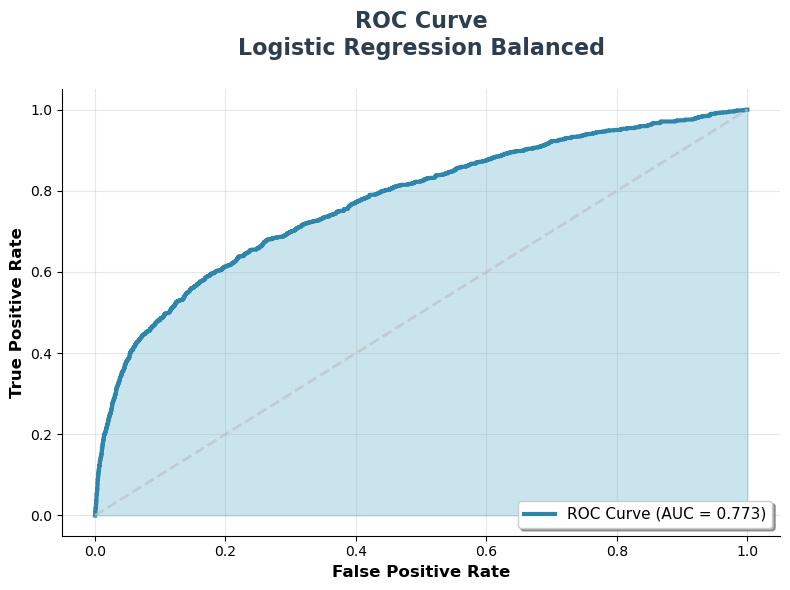

In [22]:
# =======================================
# Model 2: Logistic Regression Balanced
# =======================================

# Initialize Logistic Regression with class balancing
model_logbalanced = LogisticRegression(solver='liblinear',class_weight='balanced',max_iter=1000,random_state=42)

# Train, evaluate, and store metrics for Logistic Regression with class balancing
train_evaluate_store(
    model_logbalanced,
    X_train_combined,
    y_train,
    X_test_combined,
    y_test,
    "Logistic Regression Balanced")

The balanced Logistic Regression significantly improves recall (0.6380), meaning it detects a much larger proportion of actual subscribers. However, this comes at the cost of lower precision and overall accuracy. This trade-off is expected when handling imbalanced datasets and highlights the importance of selecting evaluation metrics aligned with business goals.

### Model 3: Random Forest "Balanced"

A Random Forest classifier is trained using GridSearchCV to optimize hyperparameters. Class imbalance is handled using class_weight="balanced", and recall is used as the scoring metric to prioritize detection of subscribers.

Fitting 3 folds for each of 18 candidates, totalling 54 fits

=============== Random Forest (Tuned) Performance ===============
Accuracy:  0.7888
Precision: 0.3030
Recall:    0.6191
F1-Score:  0.4068
ROC-AUC:   0.7867


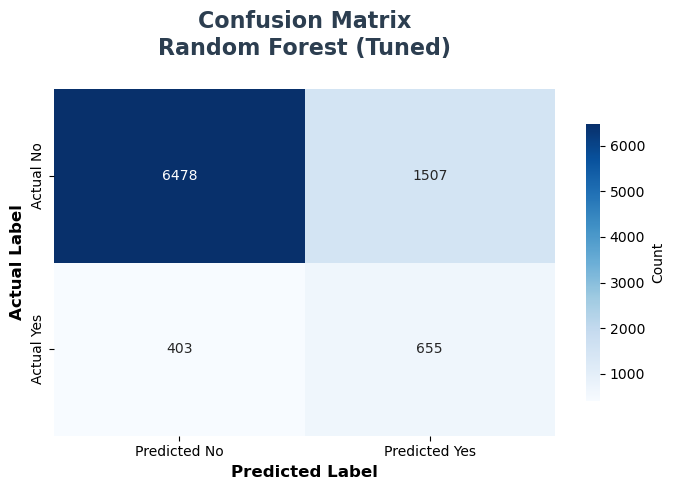

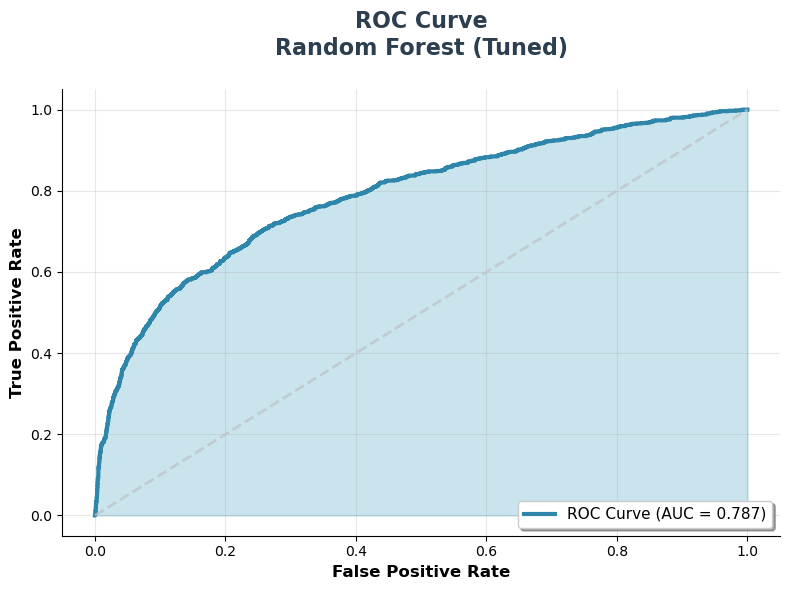

Best Random Forest parameters: {'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 300}


In [23]:
# =======================================
# Model 3: Random Forest Balanced
# =======================================

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [8, 12, 15],
    'min_samples_leaf': [2, 5, 10]}

# Start base model for tuning
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# Perform Grid Search with recall as evaluation metric
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=1)

# Fit the grid search to the training data
train_evaluate_store(grid_search_rf,X_train_combined,y_train,X_test_combined,y_test,"Random Forest (Tuned)")
best_rf = grid_search_rf.best_estimator_
print("Best Random Forest parameters:", grid_search_rf.best_params_)

The tuned Random Forest achieves a strong balance between precision and recall, with a recall of 0.6333 and improved F1-score compared to Logistic Regression models. The model captures nonlinear relationships and interactions between features, making it more effective for this classification task. It represents a significant improvement over baseline models.

### Model 4: XGBoost "Balanced"

XGBoost is a gradient boosting algorithm known for its strong performance in structured datasets. Class imbalance is handled using the scale_pos_weight parameter, and hyperparameters are optimized using GridSearchCV with recall as the scoring metric.

Fitting 3 folds for each of 32 candidates, totalling 96 fits

=============== XGBoost (Tuned) Performance ===============
Accuracy:  0.8014
Precision: 0.3259
Recall:    0.6531
F1-Score:  0.4349
ROC-AUC:   0.8010


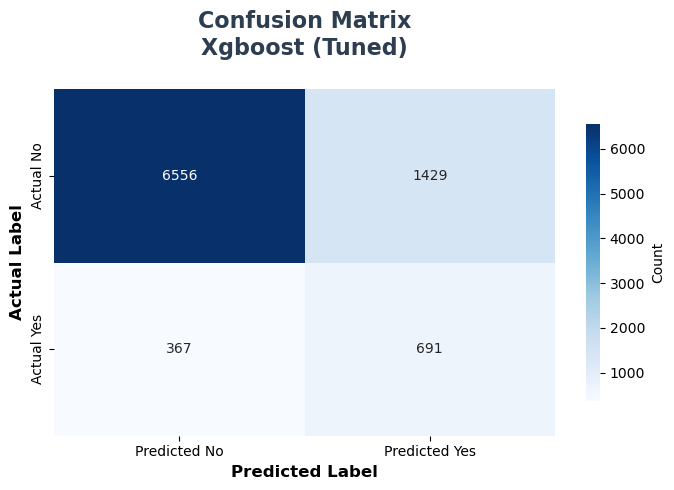

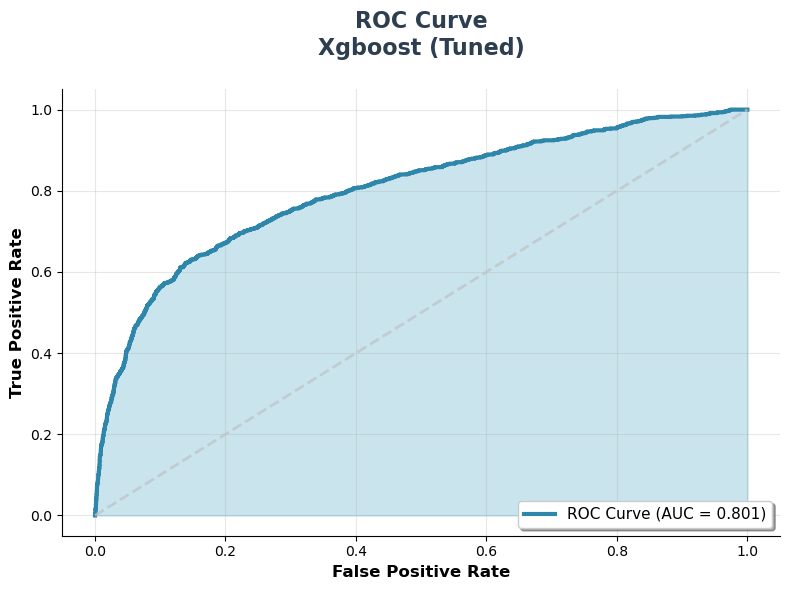

Best XGBoost parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}


In [24]:
# =======================================
# Model 4: XGBoost Balanced
# =======================================

# Compute scale_pos_weight for imbalance handling
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Define hyperparameter grid
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]}

# Initialize XGBoost model
xgb_base = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss')

# Perform Grid Search
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=1)
train_evaluate_store(grid_search_xgb,X_train_combined,y_train,X_test_combined,y_test,"XGBoost (Tuned)")
best_xgb = grid_search_xgb.best_estimator_
print("Best XGBoost parameters:", grid_search_xgb.best_params_)


XGBoost delivers the best overall performance among all evaluated models, achieving the highest metrics.

Its boosting mechanism allows the model to capture complex non-linear relationships and iteratively correct errors, improving predictive performance.

The tuned XGBoost model demonstrates strong performance in handling the imbalanced dataset, achieving a high recall (0.653), which indicates its ability to identify a large proportion of potential subscribers.

Overall, XGBoost is the most suitable model for this problem, as it balances the trade-off between missed opportunities (false negatives) and unnecessary marketing efforts (false positives).

### Insights from Model Performance

- Pipeline Logistic Regression favors the majority class (high accuracy) but fails to capture subscribers (low recall).
- Adjusting class weights improves recall at the cost of precision, highlighting the trade-off in imbalanced classification.
- Ensemble methods (Random Forest and XGBoost) provide the best balance between precision, recall, and ROC-AUC.
- Feature importance analysis (Random Forest) shows that previous interaction outcomes and contact-related variables are the most influential predictors of subscription, followed by financial indicators such as housing loan status.
- Further improvements could involve additional feature engineering and advanced sampling techniques to better handle class imbalance. Moreover, future work may explore decision threshold optimization in XGBoost to better align model predictions with business objectives.

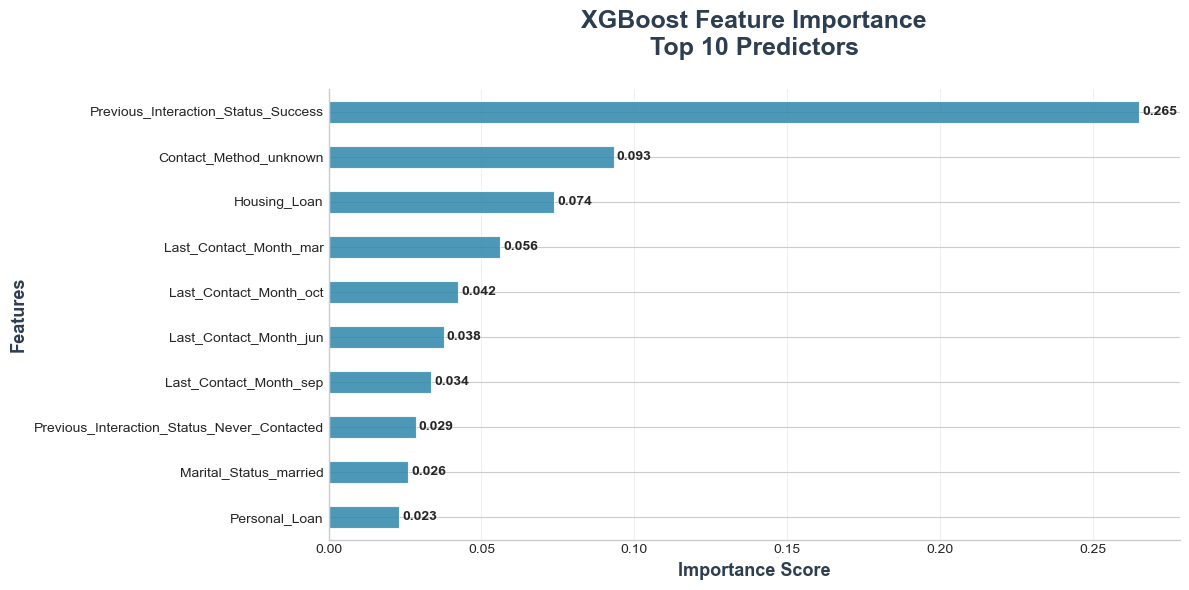

In [25]:
plt.style.use('seaborn-v0_8-whitegrid')

# Feature importance from the best XGBoost model
feature_importance = pd.Series(
    best_xgb.feature_importances_,
    index=X_train_combined.columns
).sort_values(ascending=False)


plt.figure(figsize=(12, 6))
ax = feature_importance.head(10).plot(kind='barh', 
                                     color='#2E86AB',
                                     edgecolor='white', linewidth=0.8,
                                     alpha=0.85)
plt.title("XGBoost Feature Importance\nTop 10 Predictors", 
          fontsize=18, fontweight='bold', pad=25, color='#2c3e50')
plt.xlabel('Importance Score', fontsize=13, fontweight='bold', color='#2c3e50')
plt.ylabel('Features', fontsize=13, fontweight='bold', color='#2c3e50')

for i, v in enumerate(feature_importance.head(10)):
    plt.text(v + 0.001, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=10)
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis() 
sns.despine()
plt.tight_layout()
plt.show()


Top predictors include:

- `Previous_Interaction_Status_Success` → Most predictive (strong indicator of prior successful engagement)
- `Contact_Method_unknown` → reflects missing or unknown contact method
- `Housing_Loan` → proxy for customer financial profile


The horizontal bar chart shows the relative importance of each feature in predicting term deposit subscriptions. Longer bars indicate more influential features. 

For example, `Previous_Interaction_Status_Success` is the most predictive variable, followed by `Contact_Method_unknown`, and `Housing_Loan`.

This suggests that previous customer interactions and contact-related variables play a critical role in predicting subscription behavior, while financial characteristics also contribute to the model’s decision-making.

## 6. Model Evaluation and Comparison

In this section, the trained models are evaluated on the unseen test set using a comprehensive set of performance metrics. Given the class imbalance and the business context, model comparison goes beyond accuracy to focus on metrics that better capture the ability to identify potential subscribers.

The objective is to select a model that achieves an effective balance between maximizing the identification of likely subscribers and minimizing unnecessary marketing efforts.

Accuracy is not a reliable metric in this context due to class imbalance. Therefore, greater emphasis is placed on trade-off between precision and recall.

### 6.1 Evaluation Strategy in a Marketing Campaign Context

This problem goes beyond standard classification tasks where overall accuracy is sufficient. In the context of a bank marketing campaign, different types of prediction errors have distinct business implications.

A false positive implies contacting customers who are unlikely to subscribe, increasing operational costs and reducing campaign inefficiency. Conversely, a false negative represents missed opportunities to acquire potential customers.

For this reason, multiple evaluation metrics are considered. Precision is important to minimize unnecessary contacts, while recall is critical to identify as many potential subscribers as possible.

Recall is prioritized because false negatives represent missed revenue opportunities, which are more critical than additional marketing costs.

Additionally, ROC-AUC is used to evaluate the model’s ability to discriminate between classes across different classification thresholds.

Although accuracy is reported, it is not considered sufficient on its own due to class imbalance. Therefore, model selection is based on a combination of metrics rather than a single performance indicator.

The performance metrics collected from each model are aggregated into a single DataFrame to facilitate comparison across all evaluation criteria.

In [26]:
# ================================
# 28. Model Comparison Table
# ================================

# Create a DataFrame to compare model performance metrics across all evaluated models, sorted by Recall for easy comparison of the best-performing models.
results_df = (pd.DataFrame(model_comparison).drop_duplicates(subset="Model").sort_values(by=["Recall", "Precision"], ascending=[False, False]))
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,XGBoost (Tuned),0.801393,0.325943,0.653119,0.434865,0.800951
2,Logistic Regression Balanced,0.761141,0.275469,0.638941,0.384966,0.773086
3,Random Forest (Tuned),0.788787,0.302960,0.619093,0.406832,0.786737
1,Pipeline Logistic Regression,0.893619,0.669014,0.179584,0.283159,0.772415
0,Dummy Baseline,0.883003,0.000000,0.000000,0.000000,0.500000


In [27]:
# ===========================================================
# Error Profile of Final Model: False Negatives vs False Positives
# ===========================================================

# Final predictions from the selected XGBoost model
final_pred = best_xgb.predict(X_test_combined)

# Build error analysis table using original readable test-set columns
error_profile = X_test_raw[['Previous_Interaction_Status', 'Contact_Method', 'Housing_Loan']].copy()
error_profile['Actual'] = y_test.to_numpy()
error_profile['Predicted'] = final_pred

# Label error type
error_profile['Error_Type'] = 'Correct'
error_profile.loc[(error_profile['Actual'] == 1) & (error_profile['Predicted'] == 0), 'Error_Type'] = 'False Negative'
error_profile.loc[(error_profile['Actual'] == 0) & (error_profile['Predicted'] == 1), 'Error_Type'] = 'False Positive'

# Keep only errors
error_cases = error_profile[error_profile['Error_Type'] != 'Correct'].copy()

print("Total False Negatives:", (error_cases['Error_Type'] == 'False Negative').sum())
print("Total False Positives:", (error_cases['Error_Type'] == 'False Positive').sum())

def error_distribution_table(df, variable):
    summary = (
        df.groupby([variable, 'Error_Type'])
          .size()
          .unstack(fill_value=0)
    )
    summary['Total_Errors'] = summary.sum(axis=1)
    summary['FN_%'] = (summary.get('False Negative', 0) / summary['Total_Errors'] * 100).round(1)
    summary['FP_%'] = (summary.get('False Positive', 0) / summary['Total_Errors'] * 100).round(1)
    return summary.sort_values('Total_Errors', ascending=False)

print("\nError profile by Previous_Interaction_Status")
display(error_distribution_table(error_cases, 'Previous_Interaction_Status'))

print("\nError profile by Contact_Method")
display(error_distribution_table(error_cases, 'Contact_Method'))

print("\nError profile by Housing_Loan")
display(error_distribution_table(error_cases, 'Housing_Loan'))

Total False Negatives: 367
Total False Positives: 1429

Error profile by Previous_Interaction_Status


Error_Type,False Negative,False Positive,Total_Errors,FN_%,FP_%
Previous_Interaction_Status,,,,,
Never_Contacted,306,1003,1309,23.4,76.6
Failure,42,232,274,15.3,84.7
Other,18,89,107,16.8,83.2
Success,1,105,106,0.9,99.1



Error profile by Contact_Method


Error_Type,False Negative,False Positive,Total_Errors,FN_%,FP_%
Contact_Method,,,,,
cellular,265,1279,1544,17.2,82.8
telephone,10,125,135,7.4,92.6
unknown,92,25,117,78.6,21.4



Error profile by Housing_Loan


Error_Type,False Negative,False Positive,Total_Errors,FN_%,FP_%
Housing_Loan,,,,,
0,136,1014,1150,11.8,88.2
1,231,415,646,35.8,64.2


Error profiling was used to examine whether the final model’s mistakes were concentrated in specific customer groups. False negatives and false positives were summarized by prior interaction status, contact method, and housing loan status to support a more practical interpretation of model reliability.

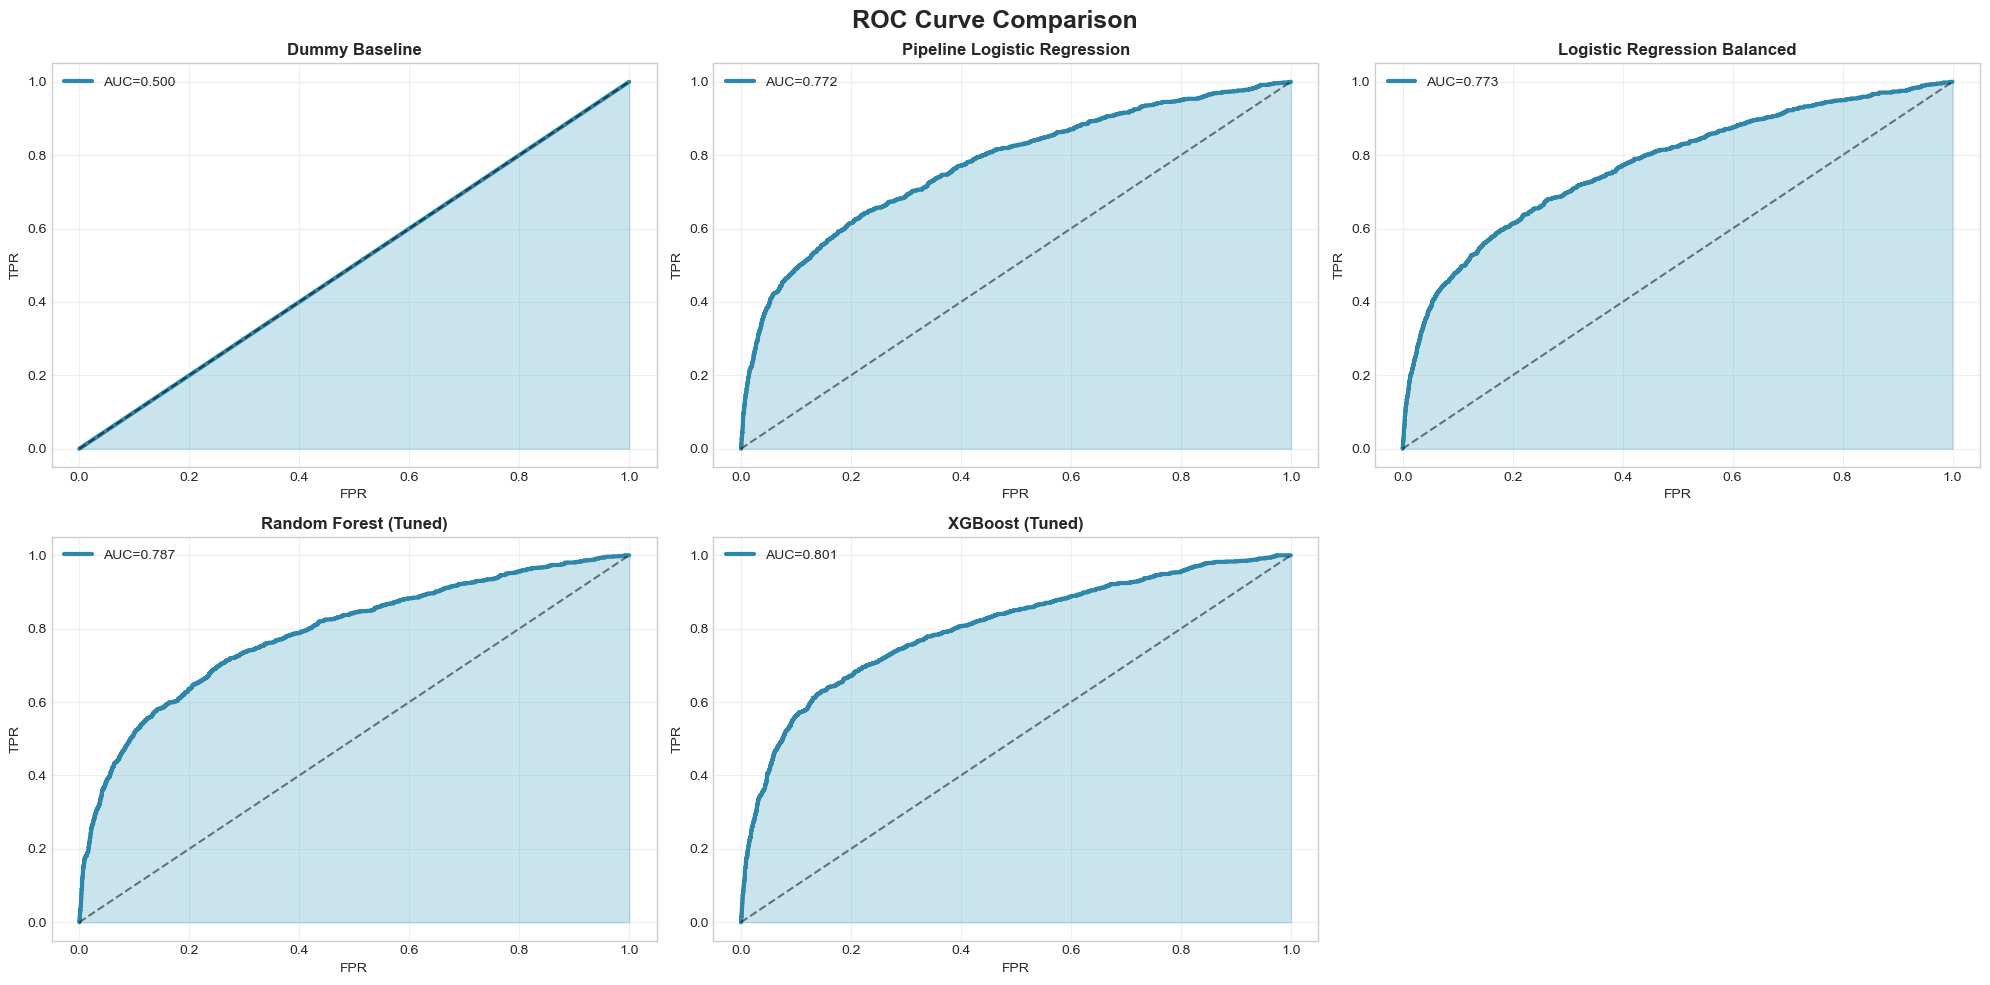

In [28]:
# ROC Curves Summary
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

model_names = list(results.keys())

for i, name in enumerate(model_names):
    fpr = results[name]['fpr']
    tpr = results[name]['tpr']
    auc_val = results[name]['auc']
    
    axes[i].plot(fpr, tpr, color='#2E86AB', lw=3, label=f'AUC={auc_val:.3f}')
    axes[i].plot([0,1],[0,1], 'k--', alpha=0.5)
    axes[i].fill_between(fpr, tpr, alpha=0.3, color='#4DA8C4')
    axes[i].set_title(f"{name}", fontweight='bold', fontsize=12)
    axes[i].set_xlabel('FPR')
    axes[i].set_ylabel('TPR')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].remove()

plt.suptitle("ROC Curve Comparison", fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

The comparison table highlights key differences in model performance:

- XGBoost (Tuned) achieves the best metric between models: recall (0.65) and precision (0.33), making it the most suitable model for deployment.

- Random Forest (Tuned) is a reasonable alternative with slightly lower F1-score and ROC-AUC.

- Logistic Regression (Balanced) improves recall compared to the pipeline Logistic Regression, but sacrifices precision.

- Pipeline Logistic Regression achieves high precision (0.67) but struggles to identify the minority class effectively.

- Dummy Baseline confirms the challenge of class imbalance, with all metrics near zero.

This comparison confirms that accuracy alone is not sufficient in imbalanced classification problems. From a business perspective, models with higher recall reduce the risk of missing potential subscribers, while precision is important to avoid excessive outreach.

While some models achieve higher precision, they fail to identify a large proportion of potential subscribers due to low recall. The XGBoost (Tuned) model provides the most effective trade-off, achieving substantially higher recall while maintaining reasonable precision, making it the most practical solution for marketing campaigns under class imbalance constraints.

### Cross-Validation of Final Model

To ensure the stability and robustness of the selected model, 5-fold cross-validation is performed using Presicion and Recall as the evaluation metrics.
This process verifies that the model’s performance is consistent across different subsets of the training data and not dependent on a single train-test split.

In [29]:
# =======================================
# 29. Cross-Validation for Final Model
# =======================================

cv_precision_scores = cross_val_score(
    best_xgb,
    X_train_combined,
    y_train,
    cv=5,
    scoring='precision')

cv_recall_scores = cross_val_score(
    best_xgb,
    X_train_combined,
    y_train,
    cv=5,
    scoring='recall')

# Results summary for cross-validation
print("Cross-Validation Results\n")

print("Precision per fold:", cv_precision_scores)
print("Mean CV Precision:", cv_precision_scores.mean(), "\n")

print("Recall per fold:", cv_recall_scores)
print("Mean CV Recall:", cv_recall_scores.mean())


Cross-Validation Results

Precision per fold: [0.33755274 0.32834032 0.32180539 0.33587302 0.33058898]
Mean CV Precision: 0.3308320910269881 

Recall per fold: [0.66193853 0.64775414 0.64817001 0.62529551 0.61702128]
Mean CV Recall: 0.6400358936142301


The model shows stable performance across folds. It achieves moderate precision (0.33) and higher recall (0.64), indicating it captures most positive cases but with some false positives.

# 7. Conclusion

This project evaluated multiple machine learning models to predict customer subscription to term deposits in a bank marketing campaign, with a strong focus on handling class imbalance and optimizing business-relevant metrics.

Among all models, XGBoost (Tuned) achieved the best overall performance:

Precision: 0.33
Recall: 0.65
F1-score: 0.43
ROC-AUC: 0.80

These results demonstrate the model’s effectiveness in identifying potential subscribers while maintaining reasonable precision, which is critical in an imbalanced classification setting.

Key takeaways:

- Class imbalance significantly impacts model performance and must be explicitly addressed.
- Accuracy alone is not a reliable metric in imbalanced classification problems.
- Ensemble methods, particularly boosting algorithms, outperform simpler models by capturing complex feature interactions.
- Customer history and engagement variables are the strongest drivers of subscription behavior.

From a business perspective, the selected model enables more efficient marketing by prioritizing customers with a higher likelihood of subscribing. This reduces unnecessary contact costs while increasing the effectiveness of campaigns.

Overall, this solution provides a robust, data-driven framework for improving decision-making in marketing campaigns.

### Future Improvements

Further enhancements could strengthen both model performance and business impact:

- Apply advanced resampling techniques such as SMOTE or undersampling to further address class imbalance.
- Perform more extensive hyperparameter optimization to refine model performance.
- Explore alternative gradient boosting models such as LightGBM or CatBoost.
- Incorporate cost-sensitive learning to directly align model optimization with business KPIs.
- Develop additional features capturing temporal patterns and customer behavior over time.
- Integrate customer lifetime value (CLV) to prioritize high-impact customers.
- Implement uplift modeling to estimate the incremental effect of marketing actions, enabling more efficient and targeted campaign strategies.
- In this analysis, all models were evaluated using the default classification threshold of 0.5. As a potential improvement, threshold optimization could be applied to better control the trade-off between recall and precision. Adjusting the decision threshold would allow the model to align more closely with business objectives, such as prioritizing higher recall to reduce missed subscription opportunities.

Overall, this modeling approach establishes a strong foundation for scalable and data-driven marketing optimization.